## `Tele-communication Customer Churn Analysis Prediction`
-----------------------------------------------------------------------------------------------------------------------------

Customer churn occurs when a customer stops using a company’s service lead to revenue loss. Analyzing churn helps businesses understand why customers leave and how to improve retention. High churn rates can affect revenue and business growth. By analyzing churn patterns businesses can take proactive steps to retain customers.

The goal of the analysis is to check or predict whether a customer will churn or not for using a tele-communication service


### `Importing Libraries`

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

### `Importing and Reading the Dataset`

In [ ]:
churn = pd.read_csv('../Dataset/Telco-Customer-Churn.csv')

churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### `Shape of the Dataset`

In [ ]:
churn.shape

(7043, 21)

### `Understanding the Dataset`

In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### `Summary Statistics`

In [ ]:
churn.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### `Handling Missing Values`

In [ ]:
churn.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### `Data Preprocessing`

In [ ]:
churn['TotalCharges'] = pd.to_numeric(churn['TotalCharges'], errors='coerce')
churn['TotalCharges'] = churn['TotalCharges'].fillna(churn['TotalCharges'].median())

### `Handling Outliers`

In [ ]:
q1 = churn.select_dtypes(include=['number']).quantile(0.25)
q3 = churn.select_dtypes(include=['number']).quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print('Lower Bound:\n', lower_bound)
print('Upper Bound:\n', upper_bound)

Lower Bound:
 SeniorCitizen        0.0000
tenure             -60.0000
MonthlyCharges     -46.0250
TotalCharges     -4674.3375
dtype: float64
Upper Bound:
 SeniorCitizen        0.0000
tenure             124.0000
MonthlyCharges     171.3750
TotalCharges      8863.1625
dtype: float64


In [ ]:
for cols in churn.select_dtypes(include=['number']).columns:
    mask = (churn[cols] < lower_bound[cols]) | (churn[cols] > upper_bound[cols])
    count = mask.sum()
    if count > 0:
        print(f'{cols} : {count} outliers | '
              f'bounds=[{lower_bound[cols]:.2f}, {upper_bound[cols]:.2f}] | '
              f'actual_min={lower_bound[cols].min():.2f}, actual_max={upper_bound[cols].max():.2f}')

SeniorCitizen : 1142 outliers | bounds=[0.00, 0.00] | actual_min=0.00, actual_max=0.00


### `Visualizing the outlier`

In [ ]:
figure = px.box(churn.select_dtypes(include=['number']), orientation='h')

figure.show()

### `Data Visualization`

#### `Gender`

In [ ]:
gender = churn['gender'].value_counts().reset_index()
gender

,gender,count
0,Male,3555
1,Female,3488


In [ ]:
gender = churn['gender'].value_counts()

label = gender.index
counts = gender.values
colors = ['green', 'blue']

fig = go.Figure(data=[go.Pie(labels=label, values=counts, hole=0.5)])
fig.update_layout(title_text='Piechart Distribution for Gender, 0 = Female, 1 = Male')
fig.update_traces(hoverinfo='label+percent', textinfo='value', marker=dict(colors=colors))

#### `Churn`

In [ ]:
target_churn = churn['Churn'].value_counts().reset_index()
target_churn

,Churn,count
0,No,5174
1,Yes,1869


In [ ]:
target_churn = churn['Churn'].value_counts()

label = target_churn.index
counts = target_churn.values
colors = ['green', 'blue']

fig = go.Figure(data=[go.Pie(labels=label, values=counts, hole=0.5)])
fig.update_layout(title_text='Piechart Distribution for Customer Churn, 0 = No, 1 = Yes')
fig.update_traces(hoverinfo='label+percent', textinfo='value', marker=dict(colors=colors))

#### `Correlation Plot`

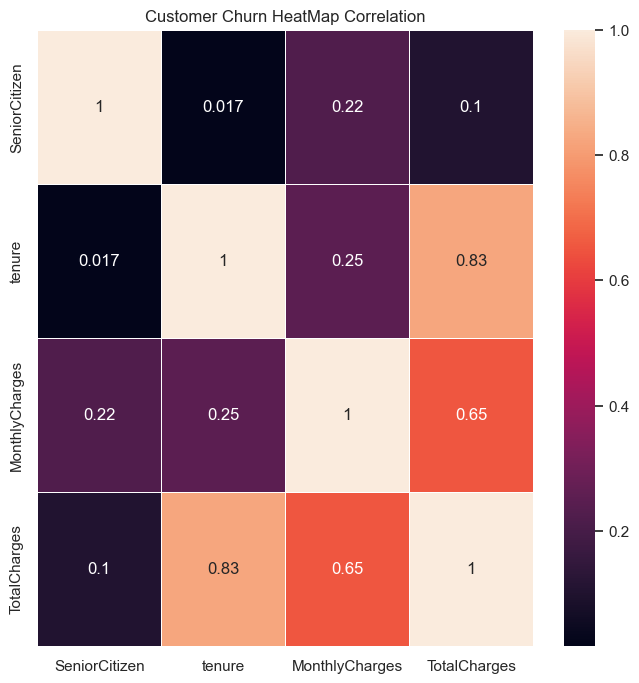

In [ ]:
churn_corr = churn.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8, 8))
sns.heatmap(churn_corr, annot=True, linewidths=0.5)
plt.title('Customer Churn HeatMap Correlation')
plt.show()

### `Handling Categorical Variables`

### `Feature Encoding`

Encoding Features Column Using OneHotEncoder and Mapping on Target/Binary Column

In [ ]:
churn['gender'] = churn['gender'].map({'Male': 1, 'Female': 0})
churn['Partner'] = churn['Partner'].map({'Yes': 1, 'No': 0})
churn['Dependents'] = churn['Dependents'].map({'Yes': 1, 'No': 0})
churn['PhoneService'] = churn['PhoneService'].map({'Yes' : 1, 'No': 0})
churn['PaperlessBilling'] = churn['PaperlessBilling'].map({'Yes': 1, 'No': 0})
churn['Churn'] = churn['Churn'].map({'Yes': 1, 'No': 0})


In [ ]:
churn = pd.get_dummies(churn, columns=['PaymentMethod', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract'], dtype=int)

churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,...,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
0,7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,...,0,1,0,0,1,0,0,1,0,0
1,5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,...,0,1,0,0,1,0,0,0,1,0
2,3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,...,0,1,0,0,1,0,0,1,0,0
3,7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,...,1,1,0,0,1,0,0,0,1,0
4,9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,...,0,1,0,0,1,0,0,1,0,0


### `Feature Selection and Splitting Data`

In [ ]:
from sklearn.model_selection import train_test_split

X = churn.drop(['Churn', 'customerID'], axis=1)
y = churn['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
X_train.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,PaymentMethod_Bank transfer (automatic),...,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year
2142,0,0,0,1,21,1,0,64.85,1336.800,0,...,0,1,0,0,0,0,1,0,1,0
1623,0,0,0,0,54,1,1,97.20,5129.450,1,...,0,0,0,1,0,0,1,0,0,1
6074,1,0,1,0,1,0,1,23.45,23.450,0,...,0,1,0,0,1,0,0,1,0,0
1362,1,0,0,0,4,1,1,70.20,237.950,0,...,0,1,0,0,1,0,0,1,0,0
6754,1,0,0,1,0,1,1,61.90,1397.475,1,...,1,1,0,0,1,0,0,0,0,1


### `Model Training, Evaluation and Cross Validation`

#### `Logistic Regression`

In [ ]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', solver='newton-cholesky', random_state=42))
])

In [ ]:
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)

print(y_pred)

[1 0 0 ... 0 0 1]


#### `Model Accuracy`

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.75


#### `Classification Report`

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.51      0.82      0.63       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



#### `RocCurveDisplay`

In [ ]:
ras = roc_auc_score(y_test, y_pred)
print(f'roc auc score: {ras:.2f}')

roc auc score: 0.77


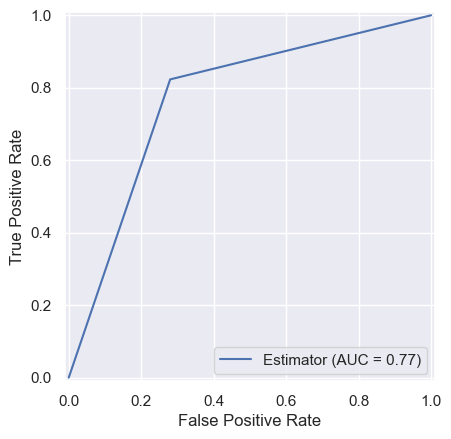

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
lr_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=lr_roc_auc, name='Estimator')
display.plot()
plt.show()

#### `Confusion Matrix`

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[746 290]
 [ 66 307]]


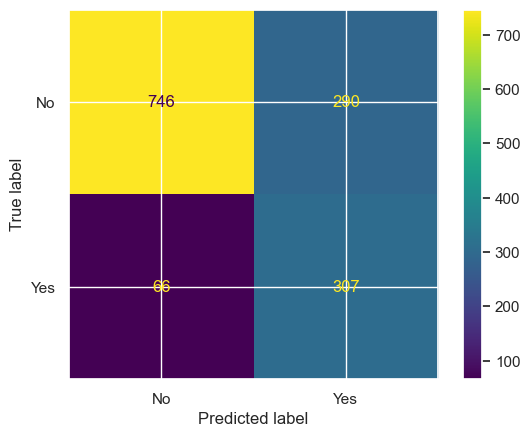

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='viridis')
plt.show()

#### `Cross Validation`

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=skf, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')


Cross-Validation Accuracy Scores: [0.75088715 0.74520937 0.75088715 0.73508523 0.74644886]
Mean Cross-Validation Accuracy: 0.746 (+/- 0.012)


#### `RandomForestClassifier`

In [ ]:
rfc = RandomForestClassifier(class_weight='balanced', n_estimators=200, criterion='log_loss', min_samples_leaf=3, min_samples_split=3, max_depth=5, max_features='sqrt', random_state=42)

rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

print(y_pred)

[1 0 0 ... 0 0 1]


#### `Model Accuracy`

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print(f'Model Accuracy: {accuracy:.2f}')

Model Accuracy: 0.76


#### `Classification Report`

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.84      0.65       373

    accuracy                           0.76      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409



#### `RocCurveDisplay`

In [ ]:
ras = roc_auc_score(y_test, y_pred)
print(f'roc auc score: {ras:.2f}')

roc auc score: 0.78


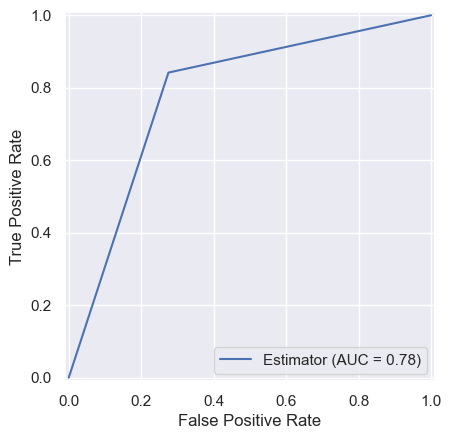

In [ ]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
rfc_roc_auc = metrics.auc(fpr, tpr)
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=rfc_roc_auc, name='Estimator')
display.plot()
plt.show()

#### `Confusion Matrix`

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[751 285]
 [ 59 314]]


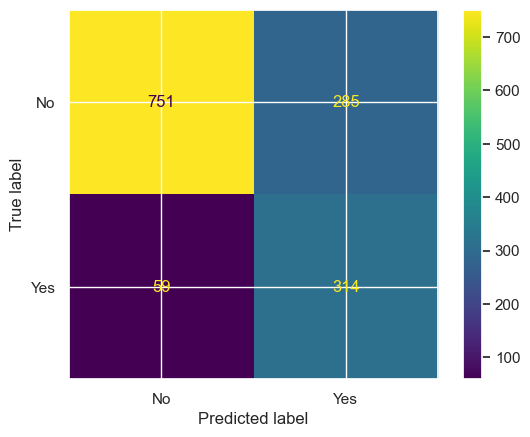

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='viridis')
plt.show()

#### `Cross Validation`

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rfc, X, y, cv=skf, scoring='accuracy')
print(f'Cross-Validation Accuracy Scores: {cv_scores}')
print(f'Mean Cross-Validation Accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})')

Cross-Validation Accuracy Scores: [0.75443577 0.74095103 0.74804826 0.74005682 0.72940341]
Mean Cross-Validation Accuracy: 0.743 (+/- 0.017)
